# Lab3: Inverse Kinematics and Dynamics

<a href="https://colab.research.google.com/drive/19HfF08S_nShxU1r4xWUC-BgDv-NG0etH">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="250">
</a>

## Introduction

A robot manipulator must solve two fundamental problems to be useful: *where should the joints be?* and *how should the joints move?* This lab addresses both questions computationally, bridging the analytical models developed in lectures with practical simulation tools.

The lab is organized in two parts. **Tasks 1–5** are guided demonstrations using a 2-link planar robot and MuJoCo physics engine, introducing the core algorithms step by step. **Problems 1–3** ask you to apply these same ideas to the first three joints of a PUMA-type spatial robot, a more realistic arm that moves in 3D.

Across the five tasks, you will see three complementary approaches to the same underlying problem: closed-form (analytical) models, iterative numerical solvers, and physics-based simulation. Understanding when each approach is appropriate, and how to verify one against another, will be a central theme of the lab.

---

## Learning Objectives

By the end of this lab you should be able to:

1. **Numerical inverse kinematics** — implement the Newton-Raphson algorithm using the Jacobian pseudo-inverse to find joint angles for a desired end-effector position, and explain how initial conditions and singularities affect convergence.

2. **Differential inverse kinematics** — derive and implement the relationship $\dot{\mathbf{q}} = J^+\dot{\mathbf{p}}$, and apply proportional task-space feedback to track both fixed targets and time-varying trajectories.

3. **Lagrangian dynamics** — assemble the inertia matrix $\mathbf{M}(\mathbf{q})$, Coriolis matrix $\mathbf{C}(\mathbf{q},\dot{\mathbf{q}})$, and gravity vector $\mathbf{g}(\mathbf{q})$ from first principles for a multi-link robot, and simulate the forward dynamics using a numerical ODE solver.

4. **Dynamics Simulation with MuJoCo** — model a robot in XML, run a forward dynamics simulation, and compare results against an analytical model to validate both.

6. **Extend 2D concepts to 3D** — generalize inverse kinematics and dynamics formulations from a planar robot to a PUMA-type spatial arm (problems for this lab).

In [ ]:
!pip install mujoco mediapy numpy
import os
import mujoco
import mediapy as media
import numpy as np


from IPython.display import clear_output
clear_output()

## Task 1: Numerical Inverse Kinematics

Given a desired end-effector position $\mathbf{Y}_d$, **numerical inverse kinematics** finds the joint angles $\boldsymbol{\theta}$ such that the forward kinematics $f(\boldsymbol{\theta}) = \mathbf{Y}_d$. Because a closed-form solution may not exist or may be difficult to derive for general manipulators, iterative (numerical) methods are commonly used.

#### Newton-Raphson Algorithm

The standard approach uses the **Jacobian pseudo-inverse** to iteratively update the joint angles:

1. **Initialize** with an initial guess $\boldsymbol{\theta}^{(0)}$.
2. **Compute the task-space error** at iteration $k$:
   $$\mathbf{e}^{(k)} = \mathbf{Y}_d - f\!\left(\boldsymbol{\theta}^{(k)}\right)$$
3. **Check convergence**: if $\|\mathbf{e}^{(k)}\| < \epsilon$, stop.
4. **Compute the Jacobian** $J(\boldsymbol{\theta}^{(k)})$, which maps joint velocities to end-effector velocities.
5. **Update the joint angles** using the pseudo-inverse $J^+$:
   $$\boldsymbol{\theta}^{(k+1)} = \boldsymbol{\theta}^{(k)} + J^+(\boldsymbol{\theta}^{(k)})\,\mathbf{e}^{(k)}$$
6. **Repeat** from step 2.

For a non-square Jacobian, the pseudo-inverse is $J^+ = J^T(JJ^T)^{-1}$ (right pseudo-inverse, used when the system is underdetermined) or $J^+ = (J^TJ)^{-1}J^T$ (left pseudo-inverse, when overdetermined). For a square, full-rank Jacobian, $J^+ = J^{-1}$.

> **Note:** Convergence depends on the initial guess and the proximity to singular configurations where $J$ loses rank. Near singularities, the update can become numerically unstable.

We will use the plannar robot with two revolute joints to illustrate the implementations. We first code the forward kinematics and Jacobian.

In [ ]:
# Link lengths
l1 = 1.0
l2 = 1.0

# ------------------------------------------------------------
# Kinematics
# ------------------------------------------------------------
def forward_kinematics(q):
    """Return joint positions and end-effector position."""
    q1, q2 = q

    p1 = np.array([
        l1 * np.cos(q1),
        l1 * np.sin(q1)
    ])

    p2 = p1 + np.array([
        l2 * np.cos(q1 + q2),
        l2 * np.sin(q1 + q2)
    ])

    return np.array([0.0, 0.0]), p1, p2


def jacobian(q):
    """2x2 Jacobian for a 2-link planar arm."""
    q1, q2 = q

    J = np.array([
        [
            -l1 * np.sin(q1) - l2 * np.sin(q1 + q2),
            -l2 * np.sin(q1 + q2)
        ],
        [
            l1 * np.cos(q1) + l2 * np.cos(q1 + q2),
            l2 * np.cos(q1 + q2)
        ]
    ])
    return J

With the forward kinematics, we can implement the numerical inverse kinematics.

In [ ]:
# ------------------------------------------------------------
# Numerical Inverse Kinematics  (Newton-Raphson, body Jacobian)
# ------------------------------------------------------------
# Target end-effector position
Y_d = np.array([0.366, 1.366])

# Initial guess for joint angles (degrees)
# You can change this to see how it will influenece the final solution and convergence speed
theta = np.array([10.0, 10.0])
theta = np.radians(theta)  # Convert to radians

# Convergence tolerance
eps = 1e-6
max_iter = 100

for i in range(max_iter):
    # Current end-effector position via forward kinematics
    _, _, Y = forward_kinematics(theta)

    # Task-space error
    e = Y_d - Y

    # Check convergence
    if np.linalg.norm(e) < eps:
        print(f"Converged in {i} iterations.")
        break

    # Jacobian pseudo-inverse update
    J = jacobian(theta)
    theta = theta + np.linalg.pinv(J) @ e # Update joint angles using the pseudo-inverse of the Jacobian
    theta = np.mod(theta, 2 * np.pi)  # Wrap each update to [0, 2pi)
    print(f"Iteration {i+1}: theta = {np.degrees(theta)}, error norm = {np.linalg.norm(e):.2e}")

print(f"Solution:  theta1 = {np.degrees(theta[0]):.4f} deg,  theta2 = {np.degrees(theta[1]):.4f} deg")
print(f"Target:    theta1 = 30.0000 deg,  theta2 = 90.0000 deg")
print(f"Final error: {np.linalg.norm(e):.2e}")

Iteration 1: theta = [342.74023322 134.95926088], error norm = 1.78e+00
Iteration 2: theta = [ 43.13869039 102.83386727], error norm = 7.87e-01
Iteration 3: theta = [24.52202349 96.58048153], error norm = 4.81e-01
Iteration 4: theta = [30.01066912 90.25352356], error norm = 9.85e-02
Iteration 5: theta = [29.99886731 90.00312034], error norm = 4.58e-03
Iteration 6: theta = [29.99946727 90.00252102], error norm = 1.05e-05
Converged in 6 iterations.
Solution:  theta1 = 29.9995 deg,  theta2 = 90.0025 deg
Target:    theta1 = 30.0000 deg,  theta2 = 90.0000 deg
Final error: 5.48e-11


## Task 2: Differential Inverse Kinematics

Differential inverse kinematics computes **joint velocities** instead of solving directly for joint angles. Starting from the differential kinematics relationship

$$\dot{\mathbf{Y}} = J(\mathbf{\theta})\,\dot{\mathbf{\theta}},$$

we use the Jacobian pseudo-inverse to map a desired end-effector velocity into a joint-space velocity command:

$$\dot{\mathbf{\theta}} = J^{+}(\mathbf{\theta})\,\dot{\mathbf{Y}}_{\mathrm{d}}.$$

This approach is useful for kinematic control because it updates the robot motion continuously and can naturally handle moving targets or trajectories. In practice, we often add proportional feedback in task space so that the desired end-effector velocity depends on the tracking error, which improves convergence to the target and reduces steady-state error.

In the next two code cells, we illustrate two common uses of differential inverse kinematics with the same 2-link planar arm:

1. In the first example, we generate a reachable target point and drive the end-effector toward it using a proportional task-space velocity command $\mathbf{v} = K(\mathbf{Y}_d - \mathbf{Y})$. The pseudo-inverse Jacobian converts this desired Cartesian velocity into joint velocities, and the configuration is updated by forward integration.
2. In the second example, the desired end-effector position changes continuously along a circle. The controller combines a feedforward term from the desired trajectory velocity with a feedback term from the position error, so the arm can track the moving path rather than only converge to a fixed point.

Because the Jacobian may become singular or ill-conditioned at some configurations, we use the pseudo-inverse in both examples for numerical robustness.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# ------------------------------------------------------------
# Random reachable target (sample joint angles, compute FK)
# ------------------------------------------------------------
np.random.seed(6) # change the values for the seed to generate different targets
Y_target = np.random.uniform(-np.pi, np.pi, size=2)
_, _, Yd = forward_kinematics(Y_target)
print(f"Random target position: x = {Yd[0]:.4f} m, y = {Yd[1]:.4f} m")
print(f"(generated from q1={np.degrees(Y_target[0]):.1f} deg, q2={np.degrees(Y_target[1]):.1f} deg)")

# ------------------------------------------------------------
# Differential IK to reach target
# ------------------------------------------------------------
dt = 0.02           # time step (s)
T  = 8.0            # total time (s)
K  = 3.0            # task-space feedback gain

q = np.array([0.5, 0.5])   # initial configuration in radians

q_history  = [q.copy()]  # store joint angles over time
ee_history = [] # store end-effector positions over time

_, _, Y = forward_kinematics(q) # compute initial end-effector position
ee_history.append(Y.copy()) # record initial end-effector position

steps = int(T / dt)
for _ in range(steps):
    _, _, Y = forward_kinematics(q)
    e = Yd - Y

    # Stop integrating once close enough
    if np.linalg.norm(e) < 1e-3:
        break

    J    = jacobian(q)
    v    = K * e                       # proportional task-space velocity
    qdot = np.linalg.pinv(J) @ v       # pseudoinverse maps to joint space
    q    = q + qdot * dt

    q_history.append(q.copy()) # record joint angles
    ee_history.append(Y.copy()) # record end-effector position

q_history  = np.array(q_history)
ee_history = np.array(ee_history)
print(f"Reached in {len(q_history)} steps  |  final error = {np.linalg.norm(Yd - ee_history[-1]):.2e} m")

# ------------------------------------------------------------
# The following code are used to animate the motion of the arm
# as it reaches the target.
# You can run this cell multiple times to see
# different random targets (change the seed value above).
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_aspect('equal')
ax.grid(True)
ax.set_title('2-Link Arm — Differential IK to Random Target')

# Target marker
ax.plot(*Yd, 'r*', ms=15, zorder=5, label='Target')

arm_line,  = ax.plot([], [], 'o-', lw=3, color='steelblue', label='Robot arm')
trace_line, = ax.plot([], [], lw=1.5, color='orange', alpha=0.7, label='EE trace')
ax.legend()

def init():
    arm_line.set_data([], [])
    trace_line.set_data([], [])
    return arm_line, trace_line

def update(frame):
    base, joint, ee = forward_kinematics(q_history[frame])
    arm_line.set_data([base[0], joint[0], ee[0]],
                      [base[1], joint[1], ee[1]])
    trace_line.set_data(ee_history[:frame+1, 0], ee_history[:frame+1, 1])
    return arm_line, trace_line

ani = FuncAnimation(fig, update, frames=len(q_history),
                    init_func=init, interval=20, blit=True)
plt.close(fig)
display(HTML(ani.to_jshtml()))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# ------------------------------------------------------------
# 2-link planar arm drawing a circle with differential IK
# ------------------------------------------------------------

# Simulation settings
dt = 0.02 # time step
T = 12.0 # total simulation time
steps = int(T / dt)

# Task-space feedback gain
K = 4.0

# Circle trajectory parameters
center = np.array([0.5, 0.2])
radius = 0.5
omega = 2 * np.pi / 6.0   # one circle every 6 seconds

# Initial joint angles
q = np.array([0.5, 0.8])

def desired_trajectory(t):
    """Desired circle position and velocity."""
    Yd = center + radius * np.array([
        np.cos(omega * t),
        np.sin(omega * t)
    ])

    Yd_dot = radius * omega * np.array([
        -np.sin(omega * t),
        np.cos(omega * t)
    ])

    return Yd, Yd_dot


# ------------------------------------------------------------
# Run simulation
# ------------------------------------------------------------
q_history = []
ee_history = []
Yd_history = []

for k in range(steps):
    t = k * dt

    # Current end-effector position
    _, _, Y = forward_kinematics(q)

    # Desired position and velocity
    Yd, Yd_dot = desired_trajectory(t)

    # Tracking error
    e = Yd - Y

    # Differential IK with task-space feedback
    Y_dot = Yd_dot + K * e
    J = jacobian(q)
    q_dot = np.linalg.pinv(J) @ Y_dot # Use pseudoinverse for robustness near singularities

    # Integrate joint velocity
    q = q + q_dot * dt

    q_history.append(q.copy())
    Yd_history.append(Yd.copy())
    ee_history.append(Y.copy())

q_history = np.array(q_history)
ee_history = np.array(ee_history)
Yd_history = np.array(Yd_history)

# ------------------------------------------------------------
# Plot trajectory
# ------------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.plot(Yd_history[:, 0], Yd_history[:, 1], '--', label='Desired circle')
plt.plot(ee_history[:, 0], ee_history[:, 1], label='Tracked path')
plt.scatter([0], [0], s=50, label='Base')
plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('2-Link Arm Trajectory Tracking with Differential IK')
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Animate the arm
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect('equal')
ax.grid(True)
ax.set_title('2-Link Arm Drawing a Circle')

# Desired path
ax.plot(Yd_history[:, 0], Yd_history[:, 1], '--', label='Desired circle')

# Arm line and traced end-effector path
arm_line, = ax.plot([], [], 'o-', lw=3, label='Robot arm')
trace_line, = ax.plot([], [], lw=2, label='End-effector trace')
target_point, = ax.plot([], [], 'rx', ms=10, mew=2, label='Desired point')

ax.legend()


def init():
    arm_line.set_data([], [])
    trace_line.set_data([], [])
    target_point.set_data([], [])
    return arm_line, trace_line, target_point


def update(frame):
    q = q_history[frame]
    base, joint, ee = forward_kinematics(q)
    Yd = Yd_history[frame]

    xs = [base[0], joint[0], ee[0]]
    ys = [base[1], joint[1], ee[1]]

    arm_line.set_data(xs, ys)
    trace_line.set_data(ee_history[:frame+1, 0], ee_history[:frame+1, 1])
    target_point.set_data([Yd[0]], [Yd[1]])

    return arm_line, trace_line, target_point


anim_step = 2
ani = FuncAnimation(
    fig,
    update,
    frames=range(0, len(q_history), anim_step),
    init_func=init,
    interval=20 * anim_step,
    blit=True
)

plt.close(fig)
display(HTML(ani.to_jshtml()))

Output hidden; open in https://colab.research.google.com to view.

## Task 3: Differential Inverse Kinematics Using Mujoco

This task is optional. We want to show that you can directly use existing Mujoco models for other robotic arms to simulate the differential inverse kinematics.

To do this, download the zip folder contains the Mujoco file for the UR5e robot on Canvas. Then you follow the steps belwo to upload to Colab.

- Open your Colab notebook

- In the left sidebar, click the folder icon to open the Files panel

- Click the upload icon (page with up-arrow) and upload the zip file `universal_robots_ur5e.zip`

Note that you can try to play with other robotic arms as long as you can find a Mujoco model for it (for instance, the collections in [Mujoco Menagerie](https://github.com/google-deepmind/mujoco_menagerie)).

This task is modified from [an open source Mujoco Tutorial](https://github.com/HaoxiangYou/MujocoTutorials/blob/main/robot_arms.ipynb).

In [ ]:
!pip install mujoco

# Set up GPU rendering.
from google.colab import files
import distutils.util
import os
import subprocess
if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.')

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

# Check if installation was succesful.
try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

# Other imports and helper functions
import time
import itertools
import numpy as np

# Graphics and plotting.
print('Installing mediapy:')
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

from IPython.display import clear_output
clear_output()

After setting up Mujoco, we can now display the robot.

Archive:  universal_robots_ur5e.zip
  inflating: universal_robots_ur5e/assets/base_0.obj  
  inflating: universal_robots_ur5e/assets/base_1.obj  
  inflating: universal_robots_ur5e/assets/forearm_0.obj  
  inflating: universal_robots_ur5e/assets/forearm_1.obj  
  inflating: universal_robots_ur5e/assets/forearm_2.obj  
  inflating: universal_robots_ur5e/assets/forearm_3.obj  
  inflating: universal_robots_ur5e/assets/shoulder_0.obj  
  inflating: universal_robots_ur5e/assets/shoulder_1.obj  
  inflating: universal_robots_ur5e/assets/shoulder_2.obj  
  inflating: universal_robots_ur5e/assets/upperarm_0.obj  
  inflating: universal_robots_ur5e/assets/upperarm_1.obj  
  inflating: universal_robots_ur5e/assets/upperarm_2.obj  
  inflating: universal_robots_ur5e/assets/upperarm_3.obj  
  inflating: universal_robots_ur5e/assets/wrist1_0.obj  
  inflating: universal_robots_ur5e/assets/wrist1_1.obj  
  inflating: universal_robots_ur5e/assets/wrist1_2.obj  
  inflating: universal_robots_ur5e/ass

""

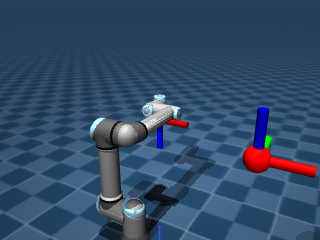

In [ ]:
!unzip -o universal_robots_ur5e.zip

# the location of the XML file
xml_path = "universal_robots_ur5e/scene.xml"


model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

# Reset the simulation to the initial keyframe.
mujoco.mj_resetDataKeyframe(model, data, 0)

# Initialize the renderer
renderer = mujoco.Renderer(model)

scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_SITE
# Make all sitegroup visible (a site in Mujoco is a point of interest, such as a sensor or a marker)
# A sitegroup is a bitmask that controls which sites are rendered.
# Setting it to 1 means all sites will be visible.
scene_option.sitegroup[:] = 1
scene_option.geomgroup[:] = 1

mujoco.mj_forward(model, data)

# Target_id
mocap_id = model.body("target").mocapid[0]
# End-effector site we wish to control, in this case a site attached to the last
# link (wrist_3_link) of the robot.
site_id = model.site("attachment_site").id

# Explicit free camera focused on end-effector
view_camera = mujoco.MjvCamera()
view_camera.type = mujoco.mjtCamera.mjCAMERA_FREE
view_camera.distance = 1.8
view_camera.azimuth = 120.0
view_camera.elevation = -20.0

def render_scene():
    view_camera.lookat[:] = data.site(site_id).xpos
    renderer.update_scene(data, camera=view_camera, scene_option=scene_option)
    return renderer.render()

media.show_image(render_scene())

### Define target trajectory

In [ ]:
import numpy as np
# Circle radius
r = 0.15
# Circle center x coordinates
cx = 0.5
# Circle centeer y cooridnates
cy = 0.0
# Trajectory freq
f = 0.5

def circle(t: float, r: float, h: float, k: float, f: float) -> np.ndarray:
    """Return the (x, y) coordinates of a circle with radius r centered at (h, k)
    as a function of time t and frequency f."""
    x = r * np.cos(2 * np.pi * f * t) + h
    y = r * np.sin(2 * np.pi * f * t) + k
    return np.array([x, y])

### Visualization helper

In [ ]:
def add_visual_capsule(scene, point1, point2, radius, rgba):
    """
    Adds one capsule to an mjvScene.
    A capsule is a cylinder with hemispherical ends, defined by two points and a radius.
    mjvScene is a data structure used in Mujoco for rendering, which contains arrays of geoms (geometric shapes) that can be visualized.
    """
    if not hasattr(mujoco, "mjv_connector"): # if the mujoco version does not support mjv_connector, skip adding the capsule
        return
    if scene.ngeom >= scene.maxgeom:
        return
    scene.ngeom += 1  # increment ngeom
    # initialise a new capsule, then connect the two points
    mujoco.mjv_initGeom(scene.geoms[scene.ngeom-1],
                        mujoco.mjtGeom.mjGEOM_CAPSULE, np.zeros(3),
                        np.zeros(3), np.zeros(9), rgba.astype(np.float32))
    mujoco.mjv_connector(scene.geoms[scene.ngeom-1],
                         mujoco.mjtGeom.mjGEOM_CAPSULE, radius,
                         np.asarray(point1, dtype=np.float64),
                         np.asarray(point2, dtype=np.float64))

def modify_scene(scn, target_traj, end_effector_traj):
    """Draw position trace."""
    if len(target_traj) > 1:
        for i in range(len(target_traj)-1):
            add_visual_capsule(scn, target_traj[i], target_traj[i+1], 0.005, np.array([0, 0, 1.0, 1.0]))
            add_visual_capsule(scn, end_effector_traj[i], end_effector_traj[i+1], 0.005, np.array([1.0, 0, 0, 0.8]))

### Simulate the desired trajectory

In [ ]:
duration = 5 # (seconds)
framerate = 30  # (Hz)

# Simulate and display video.
frames = []
end_effector_traj = []
target_traj = []

# Reset the simulation to the initial keyframe.
mujoco.mj_resetDataKeyframe(model, data, 0)

while data.time < duration:

    # Set the target position accordingly
    # mocap_pos is the position of the mocap body, which is used as the target for the end-effector to follow.
    # mocap in Mujoco is a special type of body that can be directly controlled by setting its position and orientation.
    data.mocap_pos[mocap_id, 0:2] = circle(data.time, r, cx, cy, f)
    mujoco.mj_step(model, data)

    # Updates the trajs
    target_traj.append(data.mocap_pos[mocap_id].copy())
    end_effector_traj.append(data.site(site_id).xpos.copy())

    if len(frames) < data.time * framerate:
        # Draw trajs
        view_camera.lookat[:] = data.site(site_id).xpos
        renderer.update_scene(data, camera=view_camera, scene_option=scene_option)
        modify_scene(renderer.scene, target_traj, end_effector_traj)
        pixels = renderer.render()
        frames.append(pixels)
media.show_video(frames, fps=framerate)

This browser does not support the video tag.


### Follow the target using Differential Inverse Kinematics

We implement this simply through the differential inverse kinematics

In [ ]:
duration = 8 # (seconds)
framerate = 30  # (Hz)

# Simulate and display video.
frames = []
ee_view_frames = []
end_effector_traj = []
target_traj = []

# Reset the simulation to the initial keyframe.
mujoco.mj_resetDataKeyframe(model, data, 0)

 # Pre-allocate numpy arrays.
jac = np.zeros((6, model.nv))
error = np.zeros(6)
error_pos = error[:3]
error_ori = error[3:]  # We will use this to store the orientation error in axis-angle representation
site_quat = np.zeros(4) # We will use this to store the end-effector orientation in quaternion
target_quat_conj = np.zeros(4) # We will use the conjugate of the target quaternion to calculate the error quaternion
error_quat = np.zeros(4) # We will use this to store the error quaternion

while data.time < duration:

    # Set the target position accordingly
    data.mocap_pos[mocap_id, 0:2] = circle(data.time, r, cx, cy, f)

    # We now want to track the target position with a simple differential inverse IK.

    # Get the pos error in the world frame
    # Here we update the numerical value using error_pos[:], so the error[:3] will also change accordingly
    error_pos[:] = data.site(site_id).xpos - data.mocap_pos[mocap_id]

    # Get the orientation error
    # Recall we have target_ori \times error_ori = ee_ori, so the error_ori = ee_ori \times inverse(target_ori)
    # Most mujoco embed function for orientation is quaternion based, alternative way is use scipy/jax lie etc.
    target_ori = data.mocap_quat[mocap_id]
    mujoco.mju_negQuat(target_quat_conj, target_ori) # Get the conjugate of the target quaternion, which is also the inverse for unit quaternion
    mujoco.mju_mat2Quat(site_quat, data.site(site_id).xmat) # Get the end-effector orientation in quaternion
    mujoco.mju_mulQuat(error_quat, site_quat, target_quat_conj) # Get the error quaternion by multiplying the end-effector quaternion with the inverse of the target quaternion
    # Convert error quaternion to axis-angle representation
    # We do so, as the Jacobian function we will use represent orientation error in axis-angle form
    mujoco.mju_quat2Vel(error_ori, error_quat, 1.0)

    # Get the Jacobian with respect to the end-effector site.
    # This function calculate the Jacobian of the world coordinates of a body frame
    mujoco.mj_jacSite(model, data, jac[:3], jac[3:], site_id)

    # Solve the differential IK
    # We want to have the error equal to zero
    # We take a step dq such J dq = -error
    # Note, the origin differential IK works on J v = -speed * error / dt
    # Here we implement a simple version by using dq and making Jdq = -error.
    dq = np.linalg.pinv(jac) @ -error

    # Our robot arm is position controlled, so we simple give it the target joint configure
    q = data.qpos.copy()
    # Add dq to q, here results should be the same as q = q + dq. It is different when q includes quaternian
    mujoco.mj_integratePos(model, q, dq, 1)

    # Our robot is configured to be position control
    # Here we direct set the control signal to the desired position
    np.clip(q, *model.jnt_range.T, out=q)
    data.ctrl = q

    # Step the simulation.
    mujoco.mj_step(model, data)

    # Updates the trajs
    target_traj.append(data.mocap_pos[mocap_id].copy())
    end_effector_traj.append(data.site(site_id).xpos.copy())

    # Render the scene and save frames for video.
    # frames vs. ee_view_frames: one is from a fixed camera,
    # the other is from a camera following the end-effector
    if len(frames) < data.time * framerate:
        view_camera.lookat[:] = data.site(site_id).xpos
        renderer.update_scene(data, camera=view_camera, scene_option=scene_option)
        modify_scene(renderer.scene, target_traj[::10], end_effector_traj[::10])
        pixels = renderer.render()
        frames.append(pixels)

        view_camera.lookat[:] = data.site(site_id).xpos
        renderer.update_scene(data, camera=view_camera, scene_option=scene_option)
        modify_scene(renderer.scene, target_traj[::10], end_effector_traj[::10])
        pixels = renderer.render()
        ee_view_frames.append(pixels)

media.show_video(frames, fps=framerate)
media.show_video(ee_view_frames, fps=framerate)

This browser does not support the video tag.


This browser does not support the video tag.


## Task 4: Dynamics Simulation using Analytical Models

### 4.1 Numerical Solutions of ODEs
To simulate the dynamcis, we need to first be able to numerically solve the dynamics which is simply an Ordinary Differential Equation (ODE). Let's start with a simple first-order ODE to demonstrate how to numerically solve it using SciPy's [`solve_ivp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html):

$$\frac{dx}{dt} = -2x + \sin(t)$$

with initial condition $x(0) = 1$. This represents a damped oscillator with sinusoidal forcing.

For this ODE, we can derive the analytical solution is:
$$x(t) = \frac{1}{5}(2\sin(t) - \cos(t) + 6e^{-2t})$$
We will compare the numerical solution with the analytical solution. We will use RK45 to numerically solve the ODEs. RK45 is an adaptive Runge-Kutta ODE solver.

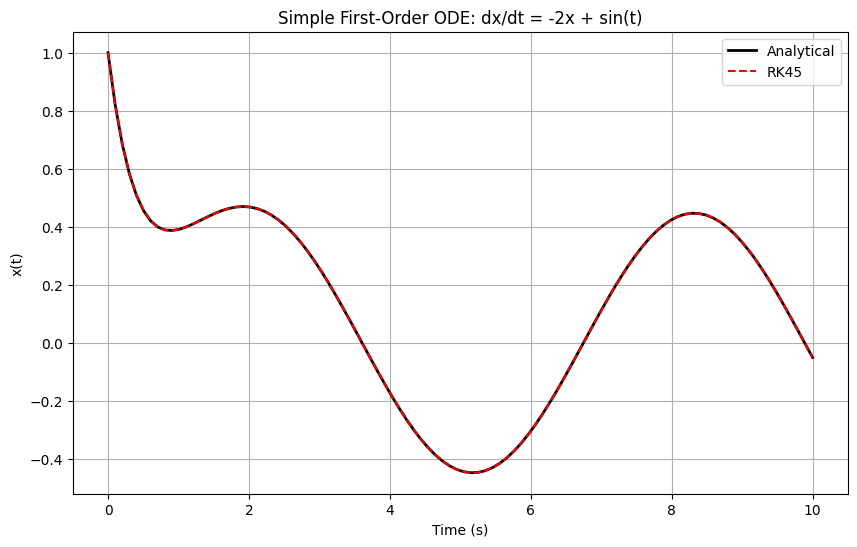

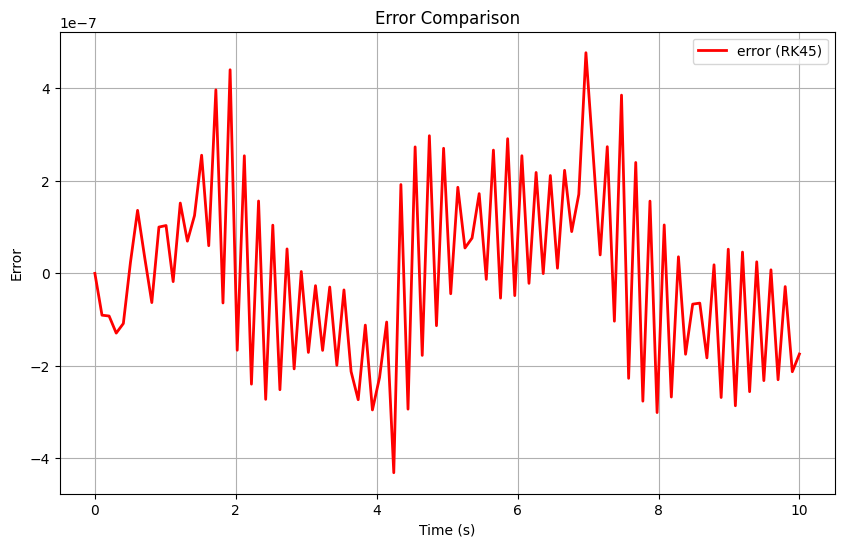

Maximum error (RK45): 4.77e-07


In [ ]:
from scipy.integrate import solve_ivp # For solving differential equations
import matplotlib.pyplot as plt

def simple_ode(t, x):
    """Simple first-order ODE: dx/dt = -2*x + sin(t)"""
    return -2*x + np.sin(t)

def analytical_solution(t):
    """Analytical solution for comparison"""
    return (2*np.sin(t) - np.cos(t) + 6*np.exp(-2*t)) / 5

# Solve the ODE
t_span = (0, 10) # time span
x0 = [1.0]  # initial condition
t_eval = np.linspace(0, 10, 100) # time points where solution is evaluated

# Using different methods
sol_rk45 = solve_ivp(simple_ode, t_span, x0, method='RK45', t_eval=t_eval, rtol=1e-8) #rtol: relative tolerance: default is 1e-3


# Analytical solution for comparison
x_analytical = analytical_solution(t_eval)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(t_eval, x_analytical, 'k-', linewidth=2, label='Analytical')
plt.plot(sol_rk45.t, sol_rk45.y[0], 'r--', label='RK45')
plt.xlabel('Time (s)')
plt.ylabel('x(t)')
plt.title('Simple First-Order ODE: dx/dt = -2x + sin(t)')
plt.legend()
plt.grid(True)

plt.figure(figsize=(10, 6))
plt.plot(t_eval, sol_rk45.y[0]-x_analytical, 'r-', linewidth=2, label='error (RK45)')
plt.xlabel('Time (s)')
plt.ylabel('Error')
plt.title('Error Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Check accuracy
error_rk45 = np.abs(sol_rk45.y[0] - analytical_solution(sol_rk45.t))
print(f"Maximum error (RK45): {np.max(error_rk45):.2e}")

### 4.2 Simulating the dynamics of a planar 2R robot
With the ODE solver, we can simulate the dynamics of 2R planar robot using the analytical models developed in lectures. As discussed in lectures, the dynamics equation for a 2R planar robot can be written as

| Symbol | Value | Description |
|--------|-------|-------------|
| $m_1$ | 1.0 kg | Mass of link 1 |
| $m_2$ | 0.8 kg | Mass of link 2 |
| $l_1$ | 0.5 m | Length of link 1 |
| $l_2$ | 0.4 m | Length of link 2 |
| $g$   | 9.81 m/s² | Gravitational acceleration |



Equation of motion

$$\mathbf{M}(\boldsymbol{\theta})\,\ddot{\boldsymbol{\theta}} + \mathbf{C}(\boldsymbol{\theta},\dot{\boldsymbol{\theta}})\,\dot{\boldsymbol{\theta}} + \mathbf{g}(\boldsymbol{\theta}) = \boldsymbol{\tau}$$



Inertia matrix $\mathbf{M}(\boldsymbol{\theta})$

$$\mathbf{M}(\boldsymbol{\theta}) = \begin{bmatrix} \alpha + 2\delta & \beta + \delta \\ \beta + \delta & \beta \end{bmatrix}$$
where
$\alpha = \frac{m_1 l_1^2}{3} + m_2 l_1^2 + \frac{m_2 l_2^2}{3}$, $\beta = \frac{m_2 l_2^2}{3}$, $\delta(\theta_2) = \frac{m_2 l_1 l_2}{2}\cos\theta_2$



Coriolis matrix $\mathbf{C}(\boldsymbol{\theta},\dot{\boldsymbol{\theta}})$

$$\mathbf{C}(\boldsymbol{\theta}, \dot{\boldsymbol{\theta}}) = \begin{bmatrix} -h\,\dot{\theta}_2 & -h\,(\dot{\theta}_1 + \dot{\theta}_2) \\[6pt] h\,\dot{\theta}_1 & 0 \end{bmatrix}$$
where $h = \dfrac{m_2 l_1 l_2}{2}\sin\theta_2$.

Gravity matrix $\mathbf{g}(\boldsymbol{\theta})$

$$\mathbf{g}(\boldsymbol{\theta}) = \begin{bmatrix} \left(\dfrac{m_1 l_1}{2} + m_2 l_1\right)g\cos\theta_1 + \dfrac{m_2 l_2}{2}\,g\cos(\theta_1+\theta_2) \\[10pt] \dfrac{m_2 l_2}{2}\,g\cos(\theta_1+\theta_2) \end{bmatrix}$$

---

#### Forward dynamics (solved at each time step)

$$\ddot{\boldsymbol{\theta}} = \mathbf{M}(\theta_2)^{-1}\bigl[\boldsymbol{\tau}(t) - \mathbf{C}(\theta_2,\dot{\boldsymbol{\theta}})\,\dot{\boldsymbol{\theta}} - \mathbf{g}(\boldsymbol{\theta})\bigr]$$

In [ ]:
"""
2R Planar Robot — Lagrangian Dynamics Simulation
=================================================
M(θ) θ̈ + C(θ, θ̇) θ̇ + g(θ) = τ

"""

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle
from pathlib import Path
from IPython.display import HTML, display

# ── Robot parameters ──────────────────────────────────────────────────────────
m1, m2 = 1.0, 0.8          # link masses [kg]
l1, l2 = 0.5, 0.4          # link lengths [m]
g_acc   = 9.81              # gravitational acceleration [m/s²]

# Constant inertia scalars (uniform-rod: I_ci = m_i l_i² / 12)
ALPHA = m1*l1**2/3 + m2*l1**2 + m2*l2**2/3
BETA  = m2*l2**2/3

# ── Torque input — edit this function ─────────────────────────────────────────
def tau(t: float) -> np.ndarray:
    """Applied joint torques [τ₁, τ₂] as a function of time.

    Examples to try:
      Constant:     return np.array([3.0, 1.0])
      Sinusoidal:   return np.array([4.0*np.sin(np.pi*t), 2.0*np.sin(2*np.pi*t)])
      Step at t=2:  return np.array([3.0, -1.5]) if t < 2.0 else np.array([-2.0, 1.0])
    """
    return np.array([0*np.sin(np.pi*t), 0.5*np.sin(2*np.pi*t)])

# ── Simulation settings ────────────────────────────────────────────────────────
T_SPAN  = (0, 6)            # simulation time window [s]
TH0     = [np.pi/6, np.pi/4]   # initial joint angles [rad]  (30°, 45°)
DTH0    = [0.0, 0.0]            # initial joint velocities [rad/s]
LABEL   = "Dynamics Simulation of 2R Planar Robot"
COLOR   = "#1D9E75"

# ── Core dynamics ──────────────────────────────────────────────────────────────

def inertia_matrix(th2: float) -> np.ndarray:
    delta = 0.5 * m2 * l1 * l2 * np.cos(th2)
    return np.array([[ALPHA + 2*delta, BETA + delta],
                     [BETA  + delta,   BETA        ]])

def coriolis_matrix(th2, dth):
    h = 0.5 * m2 * l1 * l2 * np.sin(th2)
    return np.array([[-h * dth[1],  -h * (dth[0] + dth[1])],
                     [ h * dth[0],   0.0                   ]])

def gravity_matrix(th1: float, th2: float) -> np.ndarray:
    g1 = (0.5*m1*l1 + m2*l1) * g_acc * np.cos(th1) \
       +  0.5*m2*l2           * g_acc * np.cos(th1 + th2)
    g2 =  0.5*m2*l2           * g_acc * np.cos(th1 + th2)
    return np.array([g1, g2])

def eom(t: float, state: np.ndarray) -> np.ndarray:
    """State = [θ₁, θ₂, θ̇₁, θ̇₂]  →  returns d(state)/dt."""
    th1, th2, dth1, dth2 = state
    dth  = np.array([dth1, dth2]) # angular velocity vector
    # rhs = tau(t) - coriolis_matrix(th2, dth) @ dth - gravity_matrix(th1, th2) # the right-hand side of the EOM, note the matrix-vector product for the Coriolis term
    rhs = tau(t) - coriolis_matrix(th2, dth) @ dth # this one does not have the gravity term, what does this mean?
    ddth = np.linalg.solve(inertia_matrix(th2), rhs) # This solves (M ddth = \text{rhs}) directly, which is usually more stable and faster.
    return [dth1, dth2, ddth[0], ddth[1]]

def fk(th1, th2):
    """Forward kinematics → (origin, joint1, end-effector)."""
    O  = np.array([0.0, 0.0])
    J1 = np.array([l1*np.cos(th1), l1*np.sin(th1)])
    EE = J1 + np.array([l2*np.cos(th1+th2), l2*np.sin(th1+th2)])
    return O, J1, EE

# ── Simulate ───────────────────────────────────────────────────────────────────

print("Integrating equations of motion …")
sol = solve_ivp(eom, T_SPAN, TH0 + DTH0,
                method="RK45", max_step=0.01, rtol=1e-8, atol=1e-10)
t, th1, th2 = sol.t, sol.y[0], sol.y[1]
print(f"  Done — {len(t)} steps")

# ── Build animation ────────────────────────────────────────────────────────────

fps    = 25
stride = 2
# stride = max(1, int(1 / (fps * (t[1] - t[0]))))
idx    = np.arange(0, len(t), stride)
t_s, th1_s, th2_s = t[idx], th1[idx], th2[idx]

# Precompute all the joint and end-effector positions for the animation frames
origins, joints, eefs = zip(*[fk(a, b) for a, b in zip(th1_s, th2_s)])
eefs = np.array(eefs)

fig = plt.figure(figsize=(11, 5), facecolor="#0f1117")
fig.suptitle(LABEL, color="white", fontsize=11, y=0.97, fontfamily="monospace")

# Left panel — workspace
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_facecolor("#0f1117")
reach = l1 + l2 + 0.05
ax1.set_xlim(-reach, reach); ax1.set_ylim(-reach, reach)
ax1.set_aspect("equal")
for sp in ax1.spines.values(): sp.set_color("#333")
ax1.tick_params(colors="gray")
ax1.set_xlabel("x [m]", color="gray", fontsize=9)
ax1.set_ylabel("y [m]", color="gray", fontsize=9)
ax1.grid(True, color="#1e2130", linewidth=0.5)
ax1.axhline(0, color="#222", lw=0.8); ax1.axvline(0, color="#222", lw=0.8)
ax1.add_patch(Circle((0, 0), 0.015, color="#888", zorder=5))

trail_x, trail_y = [], []
trail_line, = ax1.plot([], [], color=COLOR, lw=0.8, alpha=0.5, zorder=2)
link1_line, = ax1.plot([], [], color="white", lw=3, solid_capstyle="round", zorder=3)
link2_line, = ax1.plot([], [], color=COLOR,   lw=3, solid_capstyle="round", zorder=3)
joint1_dot, = ax1.plot([], [], "o", color="white", ms=6, zorder=4)
ee_dot,     = ax1.plot([], [], "o", color=COLOR, ms=7, zorder=5,
                        markeredgecolor="white", markeredgewidth=0.8)
time_txt = ax1.text(0.03, 0.97, "", transform=ax1.transAxes,
                    color="gray", fontsize=8, va="top", fontfamily="monospace")

# Right panel — joint angles
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_facecolor("#0f1117")
for sp in ax2.spines.values(): sp.set_color("#333")
ax2.tick_params(colors="gray")
ax2.set_xlabel("time [s]", color="gray", fontsize=9)
ax2.set_ylabel("angle [rad]", color="gray", fontsize=9)
ax2.grid(True, color="#1e2130", linewidth=0.5)
ax2.set_xlim(t_s[0], t_s[-1])
margin = 0.2
ax2.set_ylim(min(th1_s.min(), th2_s.min()) - margin,
             max(th1_s.max(), th2_s.max()) + margin)
ax2.plot(t_s, th1_s, color=COLOR,   lw=0.5, alpha=0.2)
ax2.plot(t_s, th2_s, color="white", lw=0.5, alpha=0.2)
live_th1, = ax2.plot([], [], color=COLOR,  lw=1.5, label="θ₁")
live_th2, = ax2.plot([], [], color="white", lw=1.5, label="θ₂", ls="--")
ax2.legend(loc="upper right", fontsize=8,
           facecolor="#1a1d27", edgecolor="#333", labelcolor="white")
vline = ax2.axvline(0, color="#555", lw=0.8, ls=":")

plt.tight_layout(rect=[0, 0, 1, 0.94])

def init():
    trail_line.set_data([], []); link1_line.set_data([], [])
    link2_line.set_data([], []); joint1_dot.set_data([], [])
    ee_dot.set_data([], []); live_th1.set_data([], [])
    live_th2.set_data([], []); time_txt.set_text("")
    return trail_line, link1_line, link2_line, joint1_dot, ee_dot, live_th1, live_th2, time_txt, vline

def update(frame):
    O, J1, EE = origins[frame], joints[frame], eefs[frame]
    trail_x.append(EE[0]); trail_y.append(EE[1])
    trail_line.set_data(trail_x, trail_y)
    link1_line.set_data([O[0], J1[0]], [O[1], J1[1]])
    link2_line.set_data([J1[0], EE[0]], [J1[1], EE[1]])
    joint1_dot.set_data([J1[0]], [J1[1]])
    ee_dot.set_data([EE[0]], [EE[1]])
    live_th1.set_data(t_s[:frame+1], th1_s[:frame+1])
    live_th2.set_data(t_s[:frame+1], th2_s[:frame+1])
    vline.set_xdata([t_s[frame]])
    time_txt.set_text(f"t = {t_s[frame]:.2f} s")
    return trail_line, link1_line, link2_line, joint1_dot, ee_dot, live_th1, live_th2, time_txt, vline

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(idx),
    init_func=init,
    blit=True,
    interval=1000 / fps,
)

plt.close(fig)
display(HTML(ani.to_jshtml()))

Output hidden; open in https://colab.research.google.com to view.

## Task 5: Dynamics Simulation using Mujoco

Instead of relying on analytical dynamics models, we can use MuJoCo to simulate the robot dynamics directly. MuJoCo is a physics engine for articulated rigid-body systems, where each link is modeled as a rigid body connected by joints and actuated by control inputs. At each simulation step, MuJoCo computes forward dynamics by combining inertia, Coriolis/centrifugal effects, gravity, and actuator torques to obtain joint accelerations, then integrates these accelerations over a small timestep to update velocities and positions.

A key advantage is that MuJoCo also handles constraints and contacts in a unified way, including joint limits, collisions, and external interactions. This lets us simulate more realistic robot behavior than hand-derived equations alone, while keeping the same control interface: we apply torques (or other actuator commands) and observe the resulting motion over time.


To simulate the dynamics using Mujoco, an important function is `mj_step`, which is different from `mj_forward`:

- `mj_forward` computes all kinematic and dynamic quantities for the **current** state (for example positions, velocities, Jacobians, bias forces, and contact-related terms), but it does **not** advance simulation time. It is mainly used to evaluate the current configuration.
- `mj_step` performs one full simulation step: it uses the current controls (such as joint torques), solves forward dynamics to get accelerations, integrates the state to update velocities and positions, and advances time by one timestep. Repeating `mj_step` is what generates the robot’s motion trajectory over time.

So in practice, `mj_forward` is for state evaluation, while `mj_step` is for actual time evolution of the dynamics.

In [ ]:
import os
import mujoco
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display

# ── Robot parameters (matching Task 4) ────────────────────────────────────────
m1, m2 = 1.0, 0.8      # link masses [kg]
l1, l2 = 0.5, 0.4      # link lengths [m]

# Inertia of each link as a uniform rod, about COM: I = m*L^2/12
I1_zz = m1 * l1**2 / 12
I2_zz = m2 * l2**2 / 12

# ── Step 1: Create the MuJoCo XML ─────────────────────────────────────────────
# - Robot in the XY plane, joints rotate about Z-axis
# - You can assign gravity to either enable or disable gravity term in EOM
# - <inertial> tags set exact uniform-rod inertia to match the analytical model
xml_content = f"""<mujoco model="2r_planar_robot">
  <option gravity="0 0 0" timestep="0.002" integrator="RK4"/>
  <compiler balanceinertia="true"/>

  <default>
    <joint damping="0" frictionloss="0"/>
    <motor ctrllimited="false"/>
  </default>

  <worldbody>
    <camera name="xy_plane" pos="0 0 2" euler="0 0 0" fovy="60"/>
    <light pos="0 0 3" dir="0 0 -1"/>

    <!-- Link 1: hinge at origin, uniform-rod inertia about COM -->
    <body name="link1" pos="0 0 0">
      <joint name="joint1" type="hinge" axis="0 0 1"/>
      <! We set Ixx = Iyy = I_zz/2 so that it satisfies MuJoCo's triangle inequality (A + B ≥ C)>
      <!Only Izz actually affects the dynamics. Ixx and Iyy are never "activated" in this planar setup>
      <!they're just dummy values chosen to satisfy MuJoCo's requirement.>
      <inertial pos="{l1/2:.4f} 0 0" mass="{m1}"
                diaginertia="{I1_zz/2:.6f} {I1_zz/2:.6f} {I1_zz:.6f}"/>
      <geom type="capsule" fromto="0 0 0 {l1} 0 0" size="0.025"
            rgba="0.2 0.6 0.9 1" mass="0"/>

      <!-- Link 2: hinge at end of link1 -->
      <body name="link2" pos="{l1} 0 0">
        <joint name="joint2" type="hinge" axis="0 0 1"/>
        <inertial pos="{l2/2:.4f} 0 0" mass="{m2}"
                  diaginertia="{I2_zz/2:.6f} {I2_zz/2:.6f} {I2_zz:.6f}"/>
        <geom type="capsule" fromto="0 0 0 {l2} 0 0" size="0.02"
              rgba="0.9 0.4 0.2 1" mass="0"/>
        <site name="end_effector" pos="{l2} 0 0" size="0.03" rgba="1 0 0 1"/>
      </body>
    </body>
  </worldbody>

  <actuator>
    <motor name="tau1" joint="joint1"/>
    <motor name="tau2" joint="joint2"/>
  </actuator>
</mujoco>"""

xml_path = "2r_robot.xml"
with open(xml_path, "w") as f:
    f.write(xml_content)
print(f"XML saved: {xml_path}")

# ── Step 2: Load MuJoCo model ──────────────────────────────────────────────────
model = mujoco.MjModel.from_xml_path(xml_path)
data  = mujoco.MjData(model)

# ── Step 3: Simulation settings (matching Task 4) ─────────────────────────────
T_SPAN = (0.0, 6.0)
TH0    = [np.pi/6, np.pi/4]   # initial joint angles [rad]  (30°, 45°)
DTH0   = [0.0, 0.0]           # initial joint velocities [rad/s]

def tau(t):
    """Same applied torques as Task 4."""
    return np.array([0.0 * np.sin(np.pi*t), 0.5 * np.sin(2*np.pi*t)])

# ── Step 4: Run simulation ─────────────────────────────────────────────────────
data.qpos[:] = TH0
data.qvel[:] = DTH0
mujoco.mj_forward(model, data)

dt      = model.opt.timestep
n_steps = int((T_SPAN[1] - T_SPAN[0]) / dt)
t_hist  = np.zeros(n_steps)
q_hist  = np.zeros((n_steps, 2))
dq_hist = np.zeros((n_steps, 2))

for k in range(n_steps):
    data.ctrl[:] = tau(data.time)
    mujoco.mj_step(model, data) #this advances the simulation by one time step, updating data.qpos and data.qvel according to the dynamics and the applied control
    t_hist[k]  = data.time #store the current simulation time at step k
    q_hist[k]  = data.qpos[:2].copy() #store the current joint angles (qpos) for both joints at step k
    dq_hist[k] = data.qvel[:2].copy() #store the current joint velocities (qvel) for both joints at step k

print(f"Simulation complete: {n_steps} steps, dt = {dt*1e3:.1f} ms")

# ── Step 5: Matplotlib animation (same style as Task 4) ───────────────────────
def fk(th1, th2):
    O  = np.array([0.0, 0.0])
    J1 = np.array([l1*np.cos(th1), l1*np.sin(th1)])
    EE = J1 + np.array([l2*np.cos(th1+th2), l2*np.sin(th1+th2)])
    return O, J1, EE

fps    = 25
stride = max(1, n_steps // (fps * int(T_SPAN[1] - T_SPAN[0])))
idx    = np.arange(0, n_steps, stride)
t_s    = t_hist[idx]
q1_s   = q_hist[idx, 0]
q2_s   = q_hist[idx, 1]
origins, joints, eefs = zip(*[fk(a, b) for a, b in zip(q1_s, q2_s)])
eefs = np.array(eefs)

COLOR = "#1D9E75"
fig = plt.figure(figsize=(11, 5), facecolor="#0f1117")
fig.suptitle("Task 5: Dynamics Simulation of 2R Planar Robot (MuJoCo)",
             color="white", fontsize=11, y=0.97, fontfamily="monospace")

# Left panel — workspace
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_facecolor("#0f1117")
reach = l1 + l2 + 0.05
ax1.set_xlim(-reach, reach); ax1.set_ylim(-reach, reach); ax1.set_aspect("equal")
for sp in ax1.spines.values(): sp.set_color("#333")
ax1.tick_params(colors="gray")
ax1.set_xlabel("x [m]", color="gray", fontsize=9)
ax1.set_ylabel("y [m]", color="gray", fontsize=9)
ax1.grid(True, color="#1e2130", linewidth=0.5)
ax1.axhline(0, color="#222", lw=0.8); ax1.axvline(0, color="#222", lw=0.8)

trail_x, trail_y = [], []
trail_line, = ax1.plot([], [], color=COLOR, lw=0.8, alpha=0.5, zorder=2)
link1_line, = ax1.plot([], [], color="white", lw=3, solid_capstyle="round", zorder=3)
link2_line, = ax1.plot([], [], color=COLOR,   lw=3, solid_capstyle="round", zorder=3)
joint1_dot, = ax1.plot([], [], "o", color="white", ms=6, zorder=4)
ee_dot,     = ax1.plot([], [], "o", color=COLOR, ms=7, zorder=5,
                       markeredgecolor="white", markeredgewidth=0.8)
time_txt = ax1.text(0.03, 0.97, "", transform=ax1.transAxes,
                    color="gray", fontsize=8, va="top", fontfamily="monospace")

# Right panel — joint angles
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_facecolor("#0f1117")
for sp in ax2.spines.values(): sp.set_color("#333")
ax2.tick_params(colors="gray")
ax2.set_xlabel("time [s]", color="gray", fontsize=9)
ax2.set_ylabel("angle [rad]", color="gray", fontsize=9)
ax2.grid(True, color="#1e2130", linewidth=0.5)
ax2.set_xlim(t_s[0], t_s[-1])
margin = 0.2
ax2.set_ylim(min(q1_s.min(), q2_s.min()) - margin,
             max(q1_s.max(), q2_s.max()) + margin)
ax2.plot(t_s, q1_s, color=COLOR,   lw=0.5, alpha=0.2)
ax2.plot(t_s, q2_s, color="white", lw=0.5, alpha=0.2)
live_q1, = ax2.plot([], [], color=COLOR,   lw=1.5, label="θ₁")
live_q2, = ax2.plot([], [], color="white", lw=1.5, label="θ₂", ls="--")
ax2.legend(loc="upper right", fontsize=8,
           facecolor="#1a1d27", edgecolor="#333", labelcolor="white")
vline = ax2.axvline(0, color="#555", lw=0.8, ls=":")

plt.tight_layout(rect=[0, 0, 1, 0.94])

def init():
    trail_line.set_data([], []); link1_line.set_data([], [])
    link2_line.set_data([], []); joint1_dot.set_data([], [])
    ee_dot.set_data([], []);     live_q1.set_data([], [])
    live_q2.set_data([], []);    time_txt.set_text("")
    return (trail_line, link1_line, link2_line, joint1_dot,
            ee_dot, live_q1, live_q2, time_txt, vline)

def update(frame):
    O, J1, EE = origins[frame], joints[frame], eefs[frame]
    trail_x.append(EE[0]); trail_y.append(EE[1])
    trail_line.set_data(trail_x, trail_y)
    link1_line.set_data([O[0], J1[0]],  [O[1], J1[1]])
    link2_line.set_data([J1[0], EE[0]], [J1[1], EE[1]])
    joint1_dot.set_data([J1[0]], [J1[1]])
    ee_dot.set_data([EE[0]], [EE[1]])
    live_q1.set_data(t_s[:frame+1], q1_s[:frame+1])
    live_q2.set_data(t_s[:frame+1], q2_s[:frame+1])
    vline.set_xdata([t_s[frame]])
    time_txt.set_text(f"t = {t_s[frame]:.2f} s")
    return (trail_line, link1_line, link2_line, joint1_dot,
            ee_dot, live_q1, live_q2, time_txt, vline)

ani = animation.FuncAnimation(
    fig, update, frames=len(idx),
    init_func=init, blit=True, interval=1000/fps
)
plt.close(fig)
display(HTML(ani.to_jshtml()))

Output hidden; open in https://colab.research.google.com to view.

We can also directly render the animation in Mujoco using GPU rendering.

In [ ]:
import mediapy as media

# ── Reset simulation to initial conditions ────────────────────────────────────
data.qpos[:] = TH0
data.qvel[:] = DTH0
mujoco.mj_forward(model, data)

# ── Set up renderer ───────────────────────────────────────────────────────────
fps    = 25
height, width = 480, 640
renderer = mujoco.Renderer(model, height=height, width=width)

# ── Run simulation and capture frames ─────────────────────────────────────────
frames = []
frame_dt   = 1.0 / fps   # seconds between captured frames
next_frame = 0.0

for _ in range(n_steps):
    data.ctrl[:] = tau(data.time)
    mujoco.mj_step(model, data)
    if data.time >= next_frame:
        renderer.update_scene(data, camera="xy_plane")
        frames.append(renderer.render())
        next_frame += frame_dt

renderer.close()
print(f"Captured {len(frames)} frames at {fps} fps")
media.show_video(frames, fps=fps)

Captured 301 frames at 25 fps


This browser does not support the video tag.


### Lab3 Problems

#### **Problem 1**: Numerical Inverse Kinematics for a PUMA-Type 3-DOF Arm

The first three joints of a PUMA-type robot arm are shown in Fig. 6.2 in the textbook.

**Forward Kinematics**

The end-effector position $\mathbf{p} = [p_x,\; p_y,\; p_z]^\top$ is:

$$r = a_2\cos\theta_2 + a_3\cos(\theta_2+\theta_3)$$

$$p_x = r\cos\theta_1, \quad p_y = r\sin\theta_1, \quad p_z = a_2\sin\theta_2 + a_3\sin(\theta_2+\theta_3)$$

**Geometric Jacobian**

The $3\times3$ Jacobian $J(\boldsymbol{\theta})$ such that $\dot{\mathbf{p}} = J\,\dot{\boldsymbol{\theta}}$ is:

$$J = \begin{bmatrix}
-r\sin\theta_1 & -\cos\theta_1\bigl(a_2\sin\theta_2+a_3\sin(\theta_2+\theta_3)\bigr) & -a_3\cos\theta_1\sin(\theta_2+\theta_3)\\
 r\cos\theta_1 & -\sin\theta_1\bigl(a_2\sin\theta_2+a_3\sin(\theta_2+\theta_3)\bigr) & -a_3\sin\theta_1\sin(\theta_2+\theta_3)\\
0              &  a_2\cos\theta_2+a_3\cos(\theta_2+\theta_3)                         &  a_3\cos(\theta_2+\theta_3)
\end{bmatrix}$$

The base code below provides `forward_kinematics_puma` and `jacobian_puma`.

**Your task:** implement the Newton-Raphson numerical inverse kinematics to find
$\boldsymbol{\theta}$ for a given target $\mathbf{p}_d$, following the same
algorithm used in Task 1.


In [ ]:
import numpy as np

# ── Robot parameters ──────────────────────────────────────────────────────────
a2 = 0.5   # shoulder-to-elbow length [m]
a3 = 0.4   # elbow-to-end-effector length [m]

# ── Forward Kinematics ────────────────────────────────────────────────────────
def forward_kinematics_puma(q):
    """
    3-DOF PUMA-type FK.

    Parameters
    ----------
    q : array-like, shape (3,)
        Joint angles [theta1, theta2, theta3] in radians.

    Returns
    -------
    p_elbow : ndarray, shape (3,)   – elbow position
    p_ee    : ndarray, shape (3,)   – end-effector position
    """
    t1, t2, t3 = q

    r = a2 * np.cos(t2) + a3 * np.cos(t2 + t3)   # radial reach in XY-plane

    p_elbow = np.array([
        a2 * np.cos(t2) * np.cos(t1),
        a2 * np.cos(t2) * np.sin(t1),
        a2 * np.sin(t2)
    ])

    p_ee = np.array([
        r * np.cos(t1),
        r * np.sin(t1),
        a2 * np.sin(t2) + a3 * np.sin(t2 + t3)
    ])

    return p_elbow, p_ee


# ── Geometric Jacobian ────────────────────────────────────────────────────────
def jacobian_puma(q):
    """
    3x3 geometric Jacobian for the 3-DOF PUMA-type arm.

    Parameters
    ----------
    q : array-like, shape (3,)
        Joint angles [theta1, theta2, theta3] in radians.

    Returns
    -------
    J : ndarray, shape (3, 3)
    """
    t1, t2, t3 = q

    r   = a2 * np.cos(t2) + a3 * np.cos(t2 + t3)
    s23 = a2 * np.sin(t2) + a3 * np.sin(t2 + t3)   # reused below

    J = np.array([
        [-r * np.sin(t1),  -np.cos(t1) * s23,  -a3 * np.cos(t1) * np.sin(t2 + t3)],
        [ r * np.cos(t1),  -np.sin(t1) * s23,  -a3 * np.sin(t1) * np.sin(t2 + t3)],
        [0.0,               r,                   a3 * np.cos(t2 + t3)              ]
    ])
    return J


# ── Sanity check ──────────────────────────────────────────────────────────────
q_test = np.radians([30.0, 45.0, -30.0])
_, p = forward_kinematics_puma(q_test)
J    = jacobian_puma(q_test)
print(f"Test FK  → p = {p}")
print(f"Jacobian →\n{np.round(J, 4)}")


# ══════════════════════════════════════════════════════════════════════════════
# YOUR TASK: Numerical Inverse Kinematics (Newton-Raphson)
# ══════════════════════════════════════════════════════════════════════════════
# Target end-effector position
p_d = np.array([0.35, 0.20, 0.30])   # [px, py, pz] in metres

# Initial guess (radians)
theta = np.radians([10.0, 20.0, -10.0])

# Convergence settings
eps      = 1e-6
max_iter = 100

# ------------------------------------------------------------------
# TODO: implement the Newton-Raphson loop below.
#
# At each iteration you should:
#   1. Compute the current end-effector position via forward_kinematics_puma
#   2. Compute the task-space error  e = p_d - p_ee
#   3. Check convergence: break if np.linalg.norm(e) < eps
#   4. Compute the Jacobian via jacobian_puma
#   5. Update:  theta = theta + J_pinv @ e
#
# Hint: use np.linalg.pinv(J) for the pseudo-inverse.
# ------------------------------------------------------------------

# YOUR CODE HERE


# ------------------------------------------------------------------
# After convergence, print results and verify with Forward Kinematics
# ------------------------------------------------------------------
# YOUR CODE HERE


#### **Problem 2**: Follow a 3D Circle with Differential Inverse Kinematics

Using the same 3-DOF PUMA-type arm from Problem 1, we now apply **differential
inverse kinematics** to track a moving target in 3D space — extending the 2D
circle tracking from Task 2 to three dimensions.

Given a desired task-space velocity $\dot{\mathbf{p}}_d$ and a proportional
feedback gain $K$ on the position error, the joint velocity command is:

$$\dot{\boldsymbol{\theta}} = J^+(\boldsymbol{\theta})\,\dot{\mathbf{p}}_{\text{cmd}}, \qquad
\dot{\mathbf{p}}_{\text{cmd}} = \dot{\mathbf{p}}_d + K\bigl(\mathbf{p}_d - \mathbf{p}\bigr)$$

The joint angles are then integrated forward:
$\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k + \dot{\boldsymbol{\theta}}_k\,\Delta t$.

**3D Circle Trajectory**

The desired path is a circle of radius $R$ centred at $\mathbf{c}$, lying in a
plane spanned by two orthonormal vectors $\mathbf{u}$ and $\mathbf{v}$:

$$\mathbf{p}_d(t) = \mathbf{c} + R\bigl(\cos(\omega t)\,\mathbf{u} + \sin(\omega t)\,\mathbf{v}\bigr)$$

$$\dot{\mathbf{p}}_d(t) = R\omega\bigl(-\sin(\omega t)\,\mathbf{u} + \cos(\omega t)\,\mathbf{v}\bigr)$$

Choosing $\mathbf{u} = [1,0,0]^\top$ and
$\mathbf{v} = [0,\tfrac{\sqrt{2}}{2},\tfrac{\sqrt{2}}{2}]^\top$ gives a circle
tilted 45° out of the horizontal plane.

**Your task:** complete the differential IK loop in the code below and animate
the result.




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# ── Trajectory parameters ─────────────────────────────────────────────────────
center = np.array([0.40, 0.20, 0.25])   # circle centre [m]
radius = 0.12                            # circle radius [m]
omega  = 2 * np.pi / 4.0                # angular speed [rad/s] → one lap / 4 s

# Two orthonormal vectors that define the circle plane
# u: horizontal  |  v: tilted 45° upward → genuinely 3D circle
u_vec = np.array([1.0, 0.0, 0.0])
v_vec = np.array([0.0, np.sqrt(2)/2, np.sqrt(2)/2])

def desired_trajectory(t):
    """Return desired position and velocity on the 3D circle at time t."""
    p_d    = center + radius * (np.cos(omega * t) * u_vec
                              + np.sin(omega * t) * v_vec)
    pdot_d = radius * omega * (-np.sin(omega * t) * u_vec
                              +  np.cos(omega * t) * v_vec)
    return p_d, pdot_d

# ── Simulation settings ───────────────────────────────────────────────────────
dt       = 0.02     # time step [s]
T        = 12.0     # total time [s]  (3 full laps)
K        = 5.0      # task-space feedback gain
steps    = int(T / dt)

# Initial joint angles [rad] — arm starts near the circle's t=0 point
theta = np.radians([19.0, 60.0, -90.0])

# ── History buffers ───────────────────────────────────────────────────────────
q_hist  = []
ee_hist = []
pd_hist = []

# ══════════════════════════════════════════════════════════════════════════════
# YOUR TASK: Differential IK simulation loop
# ══════════════════════════════════════════════════════════════════════════════
for k in range(steps):
    t = k * dt

    # 1. Current end-effector position (use forward_kinematics_puma from Task 6)
    # YOUR CODE HERE
    _, p = forward_kinematics_puma(theta)

    # 2. Desired position and velocity on the 3D circle
    p_d, pdot_d = desired_trajectory(t)

    # 3. TODO: compute position error
    # e = ...

    # 4. TODO: compute commanded task-space velocity (feedforward + feedback)
    # p_dot_cmd = ...

    # 5. TODO: compute Jacobian (use jacobian_puma from Task 6)
    # J = ...

    # 6. TODO: compute joint velocity using pseudo-inverse
    # theta_dot = ...

    # 7. TODO: integrate joint angles one step forward
    # theta = ...

    # Record history (do not modify)
    q_hist.append(theta.copy())
    ee_hist.append(p.copy())
    pd_hist.append(p_d.copy())

q_hist  = np.array(q_hist)
ee_hist = np.array(ee_hist)
pd_hist = np.array(pd_hist)

# ── Tracking error plot ───────────────────────────────────────────────────────
t_vec = np.arange(steps) * dt
error = np.linalg.norm(ee_hist - pd_hist, axis=1)

plt.figure(figsize=(8, 3))
plt.plot(t_vec, error * 1e3)
plt.xlabel("time [s]"); plt.ylabel("position error [mm]")
plt.title("End-effector tracking error — 3D circle")
plt.grid(True); plt.tight_layout(); plt.show()

# ── 3D animation ─────────────────────────────────────────────────────────────
# Pre-compute desired circle for reference
t_circle = np.linspace(0, 2*np.pi/omega, 200)
circle_pts = np.array([desired_trajectory(t)[0] for t in t_circle])

fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection='3d')
ax.plot(circle_pts[:,0], circle_pts[:,1], circle_pts[:,2],
        '--', color='gray', lw=1, label='Desired circle')
ax.set_xlim(-0.1, 0.9); ax.set_ylim(-0.5, 0.7); ax.set_zlim(-0.1, 0.7)
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_zlabel('z [m]')
ax.set_title('PUMA 3-DOF Arm — 3D Circle Tracking')

arm_line,   = ax.plot([], [], [], 'o-', lw=3, color='steelblue', label='Robot arm')
trace_line, = ax.plot([], [], [], lw=1.5, color='tomato', alpha=0.7, label='EE trace')
target_dot, = ax.plot([], [], [], 'x', ms=8, mew=2, color='orange', label='Desired point')
ax.legend(loc='upper left', fontsize=8)

def init():
    arm_line.set_data([], []);   arm_line.set_3d_properties([])
    trace_line.set_data([], []); trace_line.set_3d_properties([])
    target_dot.set_data([], []); target_dot.set_3d_properties([])
    return arm_line, trace_line, target_dot

def update(frame):
    q = q_hist[frame]
    p_elbow, p_ee = forward_kinematics_puma(q)
    p_d, _ = desired_trajectory(frame * dt)

    xs = [0, p_elbow[0], p_ee[0]]
    ys = [0, p_elbow[1], p_ee[1]]
    zs = [0, p_elbow[2], p_ee[2]]
    arm_line.set_data(xs, ys);    arm_line.set_3d_properties(zs)
    trace_line.set_data(ee_hist[:frame+1, 0], ee_hist[:frame+1, 1])
    trace_line.set_3d_properties(ee_hist[:frame+1, 2])
    target_dot.set_data([p_d[0]], [p_d[1]]); target_dot.set_3d_properties([p_d[2]])
    return arm_line, trace_line, target_dot

stride = 3
ani = FuncAnimation(fig, update, frames=range(0, steps, stride),
                    init_func=init, interval=dt*stride*1000, blit=False)
plt.close(fig)
display(HTML(ani.to_jshtml()))

#### **Problem 3**: Dynamics Simulation of 3-DOF PUMA-Type Robot

Using the same robot from Problems 1&2, we now simulate the **full nonlinear dynamics**. The equations of motion in matrix form are:

$$\mathbf{M}(\mathbf{q})\,\ddot{\mathbf{q}} + \mathbf{C}(\mathbf{q},\dot{\mathbf{q}})\,\dot{\mathbf{q}} + \mathbf{g}(\mathbf{q}) = \boldsymbol{\tau}$$

where $\mathbf{q} = [\theta_1,\;\theta_2,\;\theta_3]^\top$, derived from the Lagrangian for two uniform rods of masses $m_2,\,m_3$ and lengths $a_2,\,a_3$.

| Symbol | Value | Description |
|--------|-------|-------------|
| $m_2$  | 2.0 kg | Mass of link 2 (upper arm) |
| $m_3$  | 1.5 kg | Mass of link 3 (forearm) |
| $a_2$  | 0.5 m  | Length of link 2 |
| $a_3$  | 0.4 m  | Length of link 3 |
| $g$    | 9.81 m/s² | Gravitational acceleration |

---

Inertia Matrix $\mathbf{M}(\mathbf{q})$

A key structural feature of the PUMA geometry (joints 2 and 3 parallel, joint 1 perpendicular) is that $M$ is **block-diagonal**: joint 1 is inertially decoupled from joints 2–3.

$$\mathbf{M}(\mathbf{q}) = \begin{bmatrix} M_{11} & 0 & 0 \\ 0 & M_{22} & M_{23} \\ 0 & M_{23} & M_{33} \end{bmatrix}$$

Let $P = a_2\cos\theta_2 + \dfrac{a_3}{2}\cos(\theta_2+\theta_3)$ (horizontal distance from axis to COM of link 3). Then:

$$M_{11} = \frac{m_2 a_2^2}{3}\cos^2\theta_2 + m_3 P^2 + \frac{m_3 a_3^2}{12}\cos^2(\theta_2+\theta_3)$$

$$M_{22} = \frac{m_2 a_2^2}{3} + m_3\!\left(a_2^2 + \frac{a_3^2}{3} + a_2 a_3\cos\theta_3\right)$$

$$M_{23} = m_3\!\left(\frac{a_2 a_3}{2}\cos\theta_3 + \frac{a_3^2}{3}\right), \qquad M_{33} = \frac{m_3 a_3^2}{3}$$

---

Coriolis Matrix $\mathbf{C}(\mathbf{q},\dot{\mathbf{q}})$

$\mathbf{C}$ is computed from the **Christoffel symbols** of the inertia matrix:

$$C_{ij} = \sum_{k=1}^{3} \Gamma_{ijk}\,\dot{q}_k, \qquad \Gamma_{ijk} = \frac{1}{2}\!\left(\frac{\partial M_{ij}}{\partial q_k} + \frac{\partial M_{ik}}{\partial q_j} - \frac{\partial M_{jk}}{\partial q_i}\right)$$


---

Gravity Vector $\mathbf{g}(\mathbf{q})$

Joint 1 produces no gravitational torque (rotation about vertical). Joints 2 and 3 lift/lower the arm:

$$\mathbf{g}(\mathbf{q}) = \begin{bmatrix} 0 \\[4pt] \left(\dfrac{m_2 a_2}{2} + m_3 a_2\right)g\cos\theta_2 + \dfrac{m_3 a_3}{2}\,g\cos(\theta_2+\theta_3) \\[8pt] \dfrac{m_3 a_3}{2}\,g\cos(\theta_2+\theta_3) \end{bmatrix}$$

---

**Forward Dynamics**

At each time step, solve for $\ddot{\mathbf{q}}$:

$$\ddot{\mathbf{q}} = \mathbf{M}^{-1}\!\left[\boldsymbol{\tau}(t) - \mathbf{C}(\mathbf{q},\dot{\mathbf{q}})\,\dot{\mathbf{q}} - \mathbf{g}(\mathbf{q})\right]$$

**Your task:** complete the `eom` function (equations of motion) and run the simulation using `solve_ivp`.

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML, display

# ── Robot parameters ──────────────────────────────────────────────────────────
m2, m3  = 2.0, 1.5      # link masses [kg]
a2, a3  = 0.5, 0.4      # link lengths [m]
g_acc   = 9.81           # gravity [m/s²]

# ── Inertia matrix M(q) ───────────────────────────────────────────────────────
def inertia_matrix(q):
    """
    3×3 inertia matrix M(q) for the PUMA 3-DOF arm.
    Block-diagonal: joint 1 decoupled from joints 2–3.
    """
    _, t2, t3 = q
    c2  = np.cos(t2)
    c3  = np.cos(t3)
    c23 = np.cos(t2 + t3)

    P   = a2*c2 + a3/2*c23              # horizontal reach to COM of link 3

    M11 = m2*a2**2/3 * c2**2 + m3*P**2 + m3*a3**2/12 * c23**2
    M22 = m2*a2**2/3 + m3*(a2**2 + a3**2/3 + a2*a3*c3)
    M23 = m3*(a2*a3*c3/2 + a3**2/3)
    M33 = m3*a3**2/3

    return np.array([[M11, 0.0, 0.0],
                     [0.0, M22, M23],
                     [0.0, M23, M33]])

# ── Coriolis/centrifugal matrix C(q, dq) via Christoffel symbols ──────────────
def coriolis_matrix(q, dq, _eps=1e-6):
    """
    C(q, dq) computed from Christoffel symbols of M(q):
        C_ij = sum_k  Γ_ijk * dq_k
        Γ_ijk = 0.5 * (∂M_ij/∂q_k + ∂M_ik/∂q_j - ∂M_jk/∂q_i)
    Property: (M_dot - 2C) is skew-symmetric → energy consistent.
    """
    n = len(q)
    dMdq = np.zeros((n, n, n))          # dMdq[i,j,k] = ∂M_ij/∂q_k
    for k in range(n):
        qp = q.copy(); qp[k] += _eps
        qm = q.copy(); qm[k] -= _eps
        dMdq[:, :, k] = (inertia_matrix(qp) - inertia_matrix(qm)) / (2*_eps)

    C = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            C[i, j] = sum(
                0.5*(dMdq[i,j,k] + dMdq[i,k,j] - dMdq[j,k,i]) * dq[k]
                for k in range(n)
            )
    return C

# ── Gravity vector g(q) ───────────────────────────────────────────────────────
def gravity_vector(q):
    """Generalised gravity forces g(q) = ∂V/∂q."""
    _, t2, t3 = q
    c2  = np.cos(t2)
    c23 = np.cos(t2 + t3)

    g2 = (m2*a2/2 + m3*a2)*g_acc*c2 + m3*a3/2*g_acc*c23
    g3 = m3*a3/2 * g_acc * c23
    return np.array([0.0, g2, g3])

# ── Applied torques — edit this function ─────────────────────────────────────
def tau(t):
    """
    Joint torques [τ₁, τ₂, τ₃] as a function of time [N·m].
    Try:
      Gravity compensation only:  return gravity_vector(...)   # needs current q
      Step input:   return np.array([5.0, 0.0, 0.0]) if t < 3 else np.zeros(3)
      Sinusoidal:   return np.array([2*np.sin(np.pi*t), 3*np.sin(np.pi*t), 0])
    """
    return np.array([2.0*np.sin(np.pi*t), 3.0*np.sin(np.pi*t), 0.5*np.sin(2*np.pi*t)])

# ── Simulation settings ───────────────────────────────────────────────────────
T_SPAN = (0.0, 6.0)
Q0     = np.radians([30.0,  45.0, -30.0])   # initial joint angles [rad]
DQ0    = np.zeros(3)                          # initial joint velocities [rad/s]

# ══════════════════════════════════════════════════════════════════════════════
# YOUR TASK 1: Equations of motion
# ══════════════════════════════════════════════════════════════════════════════
def eom(t, state):
    """
    State vector: [θ₁, θ₂, θ₃, θ̇₁, θ̇₂, θ̇₃]
    Returns d(state)/dt = [θ̇₁, θ̇₂, θ̇₃, θ̈₁, θ̈₂, θ̈₃]

    Steps:
      1. Unpack state into q (joint angles) and dq (joint velocities)
      2. Compute M, C, g using the functions above
      3. Solve  M @ ddq = tau(t) - C @ dq - g   for ddq
         Hint: use np.linalg.solve(M, rhs)  — more stable than inverting M
      4. Return [dq[0], dq[1], dq[2], ddq[0], ddq[1], ddq[2]]
    """
    # TODO: implement this function
    pass


# ══════════════════════════════════════════════════════════════════════════════
# YOUR TASK 2: Run simulation with solve_ivp
# ══════════════════════════════════════════════════════════════════════════════
# TODO: call solve_ivp with:
#   - fun    = eom
#   - t_span = T_SPAN
#   - y0     = list(Q0) + list(DQ0)          # 6-element initial state
#   - method = 'RK45'
#   - max_step = 0.01,  rtol=1e-8,  atol=1e-10
# Then unpack:  t = sol.t;  q1,q2,q3 = sol.y[0], sol.y[1], sol.y[2]

# YOUR CODE HERE


# ── Plot joint angles ─────────────────────────────────────────────────────────
# TODO: plot θ₁, θ₂, θ₃ vs. time on the same axes (in degrees)
# Label axes, add legend, grid.

# YOUR CODE HERE


# ── 3-D animation (run after your simulation is working) ─────────────────────
def fk3(q):
    """Return base, elbow, and end-effector positions."""
    t1, t2, t3 = q
    base  = np.zeros(3)
    elbow = np.array([a2*np.cos(t2)*np.cos(t1),
                      a2*np.cos(t2)*np.sin(t1),
                      a2*np.sin(t2)])
    r     = a2*np.cos(t2) + a3*np.cos(t2+t3)
    ee    = np.array([r*np.cos(t1),
                      r*np.sin(t1),
                      a2*np.sin(t2) + a3*np.sin(t2+t3)])
    return base, elbow, ee

fps    = 25
stride = max(1, int(1/(fps*(t[1]-t[0]))))     # match real time
idx    = np.arange(0, len(t), stride)
frames_q = sol.y[:3, idx].T                    # shape (n_frames, 3)

fig = plt.figure(figsize=(7, 6), facecolor="#0f1117")
ax  = fig.add_subplot(111, projection='3d')
ax.set_facecolor("#0f1117")
ax.set_xlim(-0.95, 0.95); ax.set_ylim(-0.95, 0.95); ax.set_zlim(-0.2, 0.95)
ax.set_xlabel("x [m]", color="gray"); ax.set_ylabel("y [m]", color="gray")
ax.set_zlabel("z [m]", color="gray")
ax.tick_params(colors="gray")
fig.suptitle("Task 8: PUMA 3-DOF Dynamics Simulation",
             color="white", fontsize=10, fontfamily="monospace")

COLOR = "#1D9E75"
arm_line,   = ax.plot([], [], [], 'o-', lw=3, color=COLOR, ms=5)
trail_x, trail_y, trail_z = [], [], []
trail_line, = ax.plot([], [], [], lw=0.8, color="white", alpha=0.4)
time_txt = ax.text2D(0.03, 0.95, "", transform=ax.transAxes,
                     color="gray", fontsize=8, fontfamily="monospace")

def _init():
    arm_line.set_data([], []); arm_line.set_3d_properties([])
    trail_line.set_data([], []); trail_line.set_3d_properties([])
    return arm_line, trail_line

def _update(fi):
    q = frames_q[fi]
    base, elbow, ee = fk3(q)
    xs = [base[0], elbow[0], ee[0]]
    ys = [base[1], elbow[1], ee[1]]
    zs = [base[2], elbow[2], ee[2]]
    arm_line.set_data(xs, ys); arm_line.set_3d_properties(zs)
    trail_x.append(ee[0]); trail_y.append(ee[1]); trail_z.append(ee[2])
    trail_line.set_data(trail_x, trail_y); trail_line.set_3d_properties(trail_z)
    time_txt.set_text(f"t = {idx[fi]*( t[1]-t[0] ):.2f} s")
    return arm_line, trail_line

ani = animation.FuncAnimation(fig, _update, frames=len(idx),
                               init_func=_init, blit=True, interval=1000/fps)
plt.close(fig)
display(HTML(ani.to_jshtml()))